This simulation demonstrates the core mechanism of how GNNs work:
MESSAGE PASSING - each node learns from its neighbors iteratively.

Key Learning:
- How nodes aggregate information from neighbors
- Multi-layer message passing propagation
- Why GNNs capture relational structure better than independent models

In [ ]:
!pip install yfinance -q

In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.patches import FancyArrowPatch
import yfinance as yf

In [23]:
node_list = ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'INTC']

start_date = '2025-01-01'
end_date = '2026-01-01'

data_raw = yf.download(node_list, start=start_date, end=end_date,auto_adjust=True)
data = data_raw.xs('Close', level=0, axis=1)

print(data.head())

[*********************100%***********************]  8 of 8 completed


Ticker            AAPL        AMZN       GOOGL       INTC        META  \
Date                                                                    
2025-01-02  242.752106  220.220001  188.690994  20.219999  597.356323   
2025-01-03  242.264297  224.190002  191.041794  20.559999  602.729370   
2025-01-06  243.896927  227.610001  196.101974  19.870001  628.218994   
2025-01-07  241.119476  222.110001  194.727356  20.010000  615.947693   
2025-01-08  241.607254  222.130005  193.193359  19.879999  608.800232   

Ticker            MSFT        NVDA        TSLA  
Date                                            
2025-01-02  415.514832  138.272171  379.279999  
2025-01-03  420.249908  144.430496  410.440002  
2025-01-06  424.716949  149.389130  411.049988  
2025-01-07  419.277100  140.101669  394.359985  
2025-01-08  421.451019  140.071701  394.940002  


In [24]:
node_features = {}
for ticker in node_list:
    series = data[ticker].dropna()

    returns = pd.Series([])

    if not series.empty:
        log_price = np.log(series.iloc[-1])
        returns = series.pct_change()
        momentum = (series.iloc[-1] / series.iloc[-21]) - 1 if len(series) >= 21 else 0

        volatility = returns.rolling(window=20).std().iloc[-1] if len(returns) >= 20 else 0

        node_features[ticker] = np.array([log_price, momentum, volatility])
    else:
        node_features[ticker] = np.array([0.0, 0.0, 0.0]) # Default if no data

features_df = pd.DataFrame.from_dict(node_features, orient='index',
                                     columns=['log_price', 'momentum', 'volatility'])

print(features_df)

       log_price  momentum  volatility
AAPL    5.605287 -0.050072    0.006140
MSFT    6.181299 -0.013020    0.011153
GOOGL   5.746203 -0.008249    0.014018
AMZN    5.441638 -0.015357    0.011074
TSLA    6.108625  0.047712    0.024874
META    6.492376  0.020906    0.013683
NVDA    5.228431  0.027832    0.019318
INTC    3.608212 -0.151139    0.023750


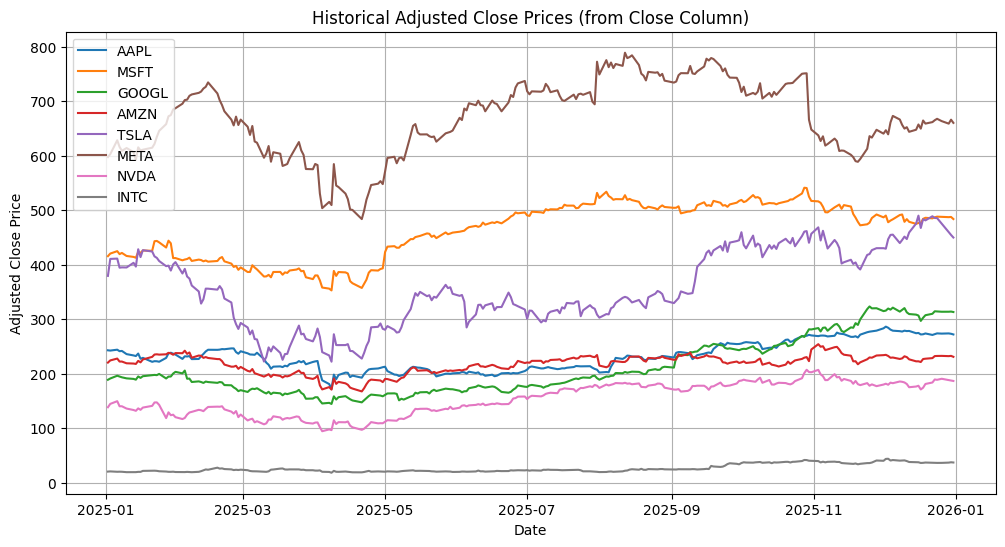

In [25]:
plt.figure(figsize=(12, 6))
for ticker in node_list:
    plt.plot(data.index, data[ticker], label=ticker)
plt.title('Historical Adjusted Close Prices (from Close Column)') # Clarified title
plt.xlabel('Date')
plt.ylabel('Adjusted Close Price')
plt.legend()
plt.grid(True)
plt.show()

## 2.Defining Network Relationships and Building Adjacency Matrix

In [26]:
edges = [
    ('AAPL', 'NVDA'),      # Apple uses Nvidia chips
    ('AAPL', 'INTC'),       # Apple uses Intel components
    ('MSFT', 'NVDA'),      # Microsoft uses Nvidia (cloud/gaming)
    ('TSLA', 'NVDA'),      # Tesla uses Nvidia chips (AI/self-driving)
    ('INTC', 'NVDA'),      # Competitive relationship between chipmakers
    ('AAPL', 'MSFT'),      # Tech sector rivalry/collaboration
    ('MSFT', 'GOOGL'),     # Cloud, AI, Search, OS competition
    ('AMZN', 'MSFT'),      # Cloud - AWS vs Azure competition
    ('AMZN', 'GOOGL'),     # Cloud, E-commerce vs Ads competition
    ('META', 'GOOGL'),     # Ads, AI, Metaverse competition
    ('AAPL', 'GOOGL'),     # OS, Search, AI competition/partnership
    ('AAPL', 'AMZN'),      # E-commerce, streaming, cloud competition
    ('AAPL', 'META'),      # VR/AR, privacy competition
    ('MSFT', 'META'),      # Metaverse, enterprise software collaboration/competition
    ('MSFT', 'INTC'),      # PC/server components supply chain
    ('GOOGL', 'NVDA'),     # AI chip usage/development, competition in custom chips
    ('GOOGL', 'INTC'),     # Server components supply chain
    ('AMZN', 'NVDA'),      # AWS uses Nvidia GPUs, developing own chips
    ('AMZN', 'INTC'),      # AWS servers use Intel processors
    ('META', 'NVDA')       # AI infrastructure uses Nvidia GPUs
]

In [27]:
n_nodes = len(node_list)
adj_matrix = np.zeros((n_nodes, n_nodes), dtype=int)

for node1, node2 in edges:
  i = node_list.index(node1)
  j = node_list.index(node2)
  adj_matrix[i, j] = 1
  adj_matrix[j, i] = 1

print("Adjacency Matrix (representing network connections):")
adj_df = pd.DataFrame(adj_matrix, index=node_list, columns=node_list)
print(adj_df)
print()

Adjacency Matrix (representing network connections):
       AAPL  MSFT  GOOGL  AMZN  TSLA  META  NVDA  INTC
AAPL      0     1      1     1     0     1     1     1
MSFT      1     0      1     1     0     1     1     1
GOOGL     1     1      0     1     0     1     1     1
AMZN      1     1      1     0     0     0     1     1
TSLA      0     0      0     0     0     0     1     0
META      1     1      1     0     0     0     1     0
NVDA      1     1      1     1     1     1     0     1
INTC      1     1      1     1     0     0     1     0



## 3.Implement Message Passing (One Layer)

```
Input features X shape: (5, 3) (Number of nodes, Input feature dimension)

Weight matrix W shape: (3, 4) (Input feature dimension, Output feature dimension)

Bias vector b shape: (4,) (Output feature dimension)

Expected output features shape: (5, 4) (Number of nodes, Output feature dimension)
```

In [28]:
np.random.seed(42) # for reproducibility
W = np.random.randn(features_df.shape[1], 4) * 0.1  # Maps 3 input features to 4 output features
b = np.zeros(4) # Bias vector, same dimension as output features

X = features_df.values # Shape: (n_nodes, n_features)

def message_passing_layer(X_input, adj_matrix, W_layer, b_layer, activation='relu'):
    n_nodes = X_input.shape[0]
    output_features_dim = W_layer.shape[1]
    X_output = np.zeros((n_nodes, output_features_dim))

    # Iterate through each node to compute its new representation
    for i in range(n_nodes):
        # Get the indices of neighbors of node i (where adj_matrix[i, j] > 0)
        neighbors_indices = np.where(adj_matrix[i] > 0)[0]
        # Include the node itself for self-information aggregation (common in GCNs)
        # Using np.unique to handle potential duplicates if self-loop already exists
        # (though our adj_matrix doesn't have explicit self-loops, it's good practice)
        neighborhood_indices = np.unique(np.concatenate([neighbors_indices, [i]]))

        # Aggregate neighbor features (mean aggregation is a simple choice)
        # Get features of all nodes in the neighborhood
        neighborhood_features = X_input[neighborhood_indices] # Shape: (num_neighbors_including_self, input_features_dim)
        aggregated_features = np.mean(neighborhood_features, axis=0) # Shape: (input_features_dim,)

        # Transform aggregated features using weights and bias
        transformed_features = aggregated_features @ W_layer + b_layer # Shape: (output_features_dim,)

        # Apply activation function
        if activation == 'relu':
            X_output[i] = np.maximum(transformed_features, 0)
        else: # Default to linear activation
            X_output[i] = transformed_features

    return X_output

X_layer1 = message_passing_layer(X, adj_matrix, W, b, activation='relu')

print("After Message Passing Layer 1:")
layer1_df = pd.DataFrame(X_layer1, index=node_list,
                        columns=[f'feat_{i+1}' for i in range(X_layer1.shape[1])])
print(layer1_df)


After Message Passing Layer 1:
         feat_1  feat_2    feat_3    feat_4
AAPL   0.271766     0.0  0.349488  0.830657
MSFT   0.271766     0.0  0.349488  0.830657
GOOGL  0.271766     0.0  0.349488  0.830657
AMZN   0.263501     0.0  0.337207  0.804137
TSLA   0.279642     0.0  0.372085  0.865203
META   0.290116     0.0  0.377634  0.890136
NVDA   0.275437     0.0  0.356056  0.843433
INTC   0.263501     0.0  0.337207  0.804137


## 4.Understanding Information Flow

```
Message passing creates a COMPUTATIONAL GRAPH where information flows
through the network:

Example: Apple's updated representation includes:
1. Its own features (direct influence)
2. Features of connected neighbors (1-hop influence)
   - Nvidia (supplies chips)
   - Intel (supplies components)
3. Through multiple layers, Apple indirectly influences Tesla
   because Tesla connects to Nvidia which connects to Apple
```

In [29]:
apple_idx = node_list.index('AAPL')
nvidia_idx = node_list.index('NVDA')
tesla_idx = node_list.index('TSLA')

apple_neighbors = np.where(adj_matrix[apple_idx] > 0)[0]
print(f"\nApple's direct neighbors: {[node_list[i] for i in apple_neighbors]}")

tesla_neighbors = np.where(adj_matrix[tesla_idx] > 0)[0]
print(f"Tesla's direct neighbors: {[node_list[i] for i in tesla_neighbors]}")


Apple's direct neighbors: ['MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'INTC']
Tesla's direct neighbors: ['NVDA']


Apple and Tesla don't directly connect,

but through Nvidia (and potentially Intel),

information flows: Apple → Nvidia ← Tesla

## 5.Multi-Layer Message Passing (Deeper Network)

```
{markdown}
Input features X_layer1 shape: (5, 4) (from previous layer)

Weight matrix W2 shape: (4, 3)

Bias vector b2 shape: (3,)

Expected output features shape: (5, 3) (Number of nodes, Output feature dimension)
```

In [30]:
np.random.seed(43) # Using a different seed for second layer weights
W2 = np.random.randn(X_layer1.shape[1], 3) * 0.1 # Maps 4 input features (from layer 1) to 3 output features
b2 = np.zeros(3) # Bias vector for the second layer

X_layer2 = message_passing_layer(X_layer1, adj_matrix, W2, b2, activation='relu')

print("After Message Passing Layer 2 (3 output features):")
layer2_df = pd.DataFrame(X_layer2, index=node_list,
                        columns=[f'feat_{i+1}' for i in range(X_layer2.shape[1])])
print(layer2_df)

After Message Passing Layer 2 (3 output features):
       feat_1    feat_2    feat_3
AAPL      0.0  0.016913  0.071949
MSFT      0.0  0.016913  0.071949
GOOGL     0.0  0.016913  0.071949
AMZN      0.0  0.016612  0.071067
TSLA      0.0  0.018375  0.074371
META      0.0  0.017282  0.073039
NVDA      0.0  0.017226  0.072430
INTC      0.0  0.016612  0.071067


## 6.Visualizing Receptive Field Growth
--------------------------------------------------------------------------------

```markdown
RECEPTIVE FIELD: The set of input nodes that influence a node's output.

Layer 0 (input): Each node only knows itself
Layer 1: Each node knows itself + direct neighbors (1-hop)
Layer 2: Each node knows itself + 1-hop + 2-hop neighbors
...
Layer k: Each node knows itself + k-hop neighbors

This is why GNNs can capture multi-hop influence in networks!
```

To explicitly demonstrate this, we'll build the receptive field for 'AAPL' (Apple) across multiple layers using the `get_receptive_field` function. This function will identify all nodes that can influence Apple's representation up to a certain number of hops.

In [31]:
def get_receptive_field(node_idx, adj_matrix, num_layers):
    """Get all nodes within k hops of a node."""
    reachable = {0: {node_idx}}  # Layer 0 is just self
    current_layer = {node_idx}

    for layer in range(1, num_layers + 1):
        next_layer = set()
        for node in current_layer:
            neighbors = set(np.where(adj_matrix[node] > 0)[0])
            next_layer.update(neighbors)
        # This original implementation of 'reachable' stores only the nodes at that specific hop depth,
        # not the cumulative set of all nodes within k hops.
        reachable[layer] = next_layer.copy()
        current_layer = next_layer

    return reachable

# Ensure apple_idx is defined
apple_idx = node_list.index('AAPL')

# Call the function for 'AAPL' for 3 layers, consistent with original notebook's example
receptive_field = get_receptive_field(apple_idx, adj_matrix, 3)

print("Apple's Receptive Field at Each Layer (Distinct Hops):")
for layer, nodes in receptive_field.items():
    node_names = [node_list[i] for i in sorted(list(nodes))]
    print(f"  Layer {layer}: {node_names}")
print()


Apple's Receptive Field at Each Layer (Distinct Hops):
  Layer 0: ['AAPL']
  Layer 1: ['MSFT', 'GOOGL', 'AMZN', 'META', 'NVDA', 'INTC']
  Layer 2: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'INTC']
  Layer 3: ['AAPL', 'MSFT', 'GOOGL', 'AMZN', 'TSLA', 'META', 'NVDA', 'INTC']



## 7.Visualizing Network and Information Flow

Saved: sim2_message_passing_real_data.png



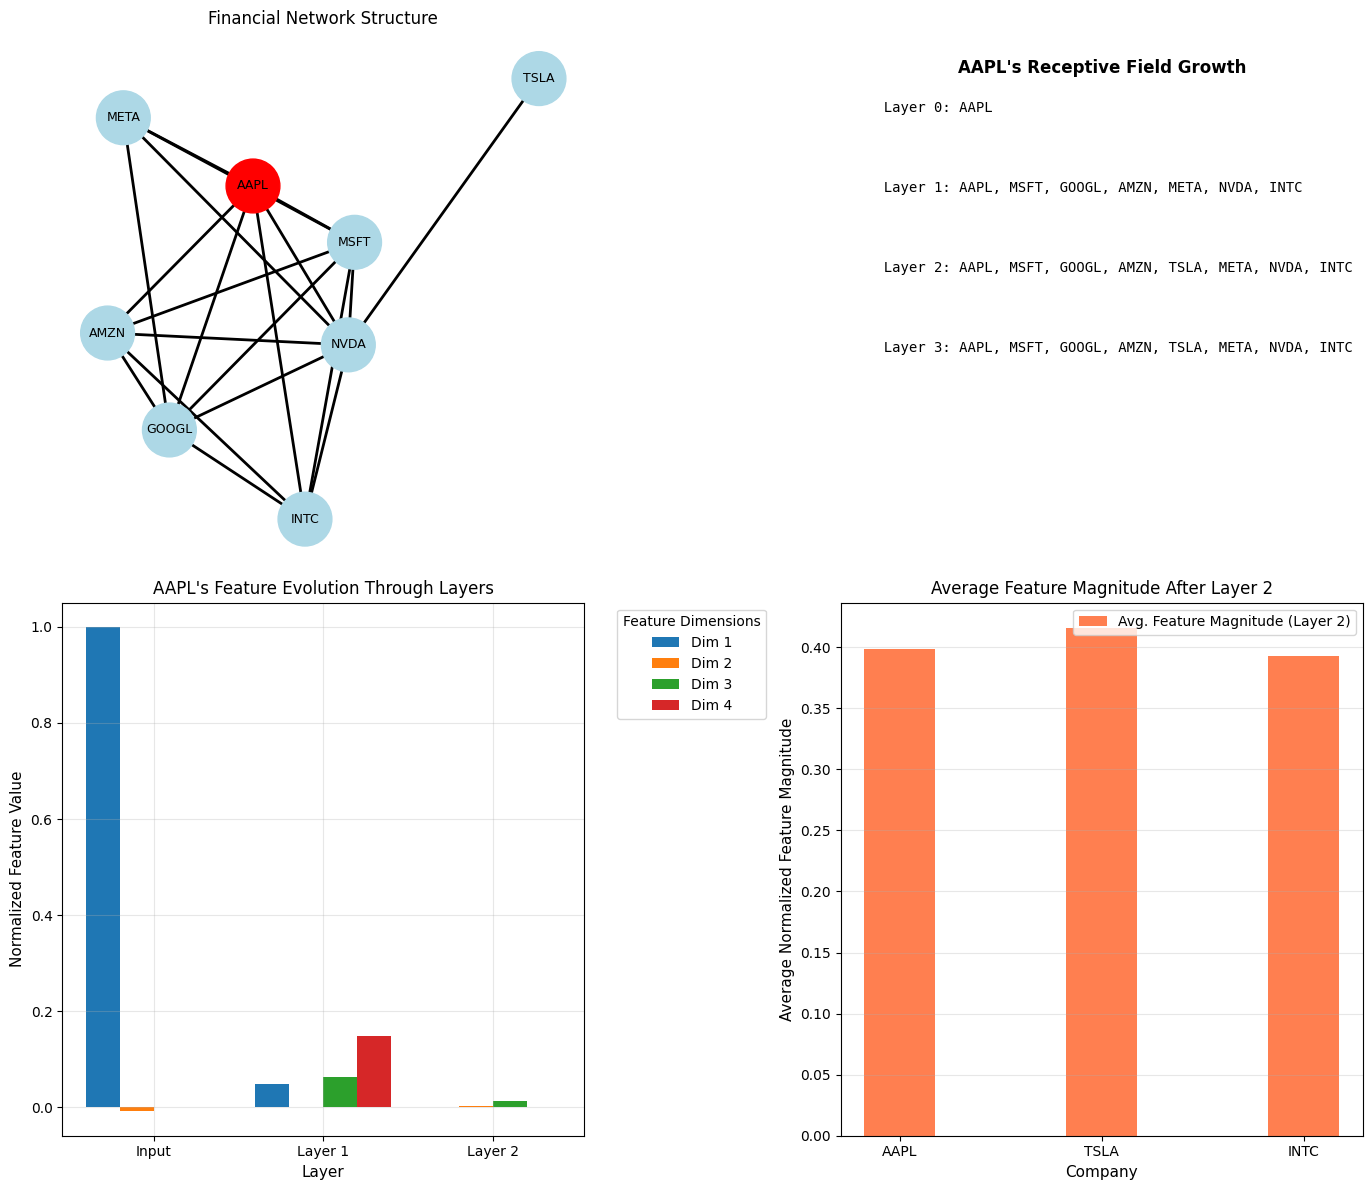

In [32]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Network structure
ax = axes[0, 0]
G = nx.Graph()
for node in node_list:
    G.add_node(node)
for node1, node2 in edges:
    G.add_edge(node1, node2)

pos = nx.spring_layout(G, seed=42, k=2) # k adjusts distance between nodes

# Highlight Apple's node in the network
colors = ['lightblue'] * len(node_list)
apple_idx_for_plot = node_list.index('AAPL')
colors[apple_idx_for_plot] = 'red'

nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=1500, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=9, ax=ax)
nx.draw_networkx_edges(G, pos, width=2, ax=ax)
ax.set_title('Financial Network Structure')
ax.axis('off')

# 2. Receptive field layers (textual explanation)
ax = axes[0, 1]
ax.text(0.5, 0.95, "AAPL's Receptive Field Growth",
        ha='center', va='top', fontsize=12, weight='bold',
        transform=ax.transAxes)

y_pos = 0.85
# Re-calculate receptive_field to get cumulative reachable nodes per layer
def get_cumulative_receptive_field(node_idx, adj_matrix, num_layers):
    reachable_sets = {0: {node_idx}}
    all_reachable = {node_idx}
    current_neighbors = {node_idx}

    for layer in range(1, num_layers + 1):
        next_hop_neighbors = set()
        for node in current_neighbors:
            neighbors = set(np.where(adj_matrix[node] > 0)[0])
            next_hop_neighbors.update(neighbors)

        # Remove nodes already processed in previous hops to show distinct new neighbors
        new_neighbors = next_hop_neighbors - all_reachable
        all_reachable.update(next_hop_neighbors)
        reachable_sets[layer] = all_reachable.copy()
        current_neighbors = next_hop_neighbors
    return reachable_sets

cumulative_receptive_field = get_cumulative_receptive_field(apple_idx, adj_matrix, 3)

for layer, nodes in cumulative_receptive_field.items():
    node_names = [node_list[i] for i in sorted(list(nodes))]
    text = f"  Layer {layer}: {', '.join(node_names)}"
    ax.text(0.05, y_pos - layer*0.15, text, fontsize=10,
           transform=ax.transAxes, family='monospace')

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis('off')

# 3. Feature evolution for Apple
ax = axes[1, 0]
feature_evolution = [
    X[apple_idx, :],  # Initial features
    X_layer1[apple_idx, :],  # Layer 1 features (padded if output dim is different)
    X_layer2[apple_idx, :]   # Layer 2 features (padded)
]

# Normalize for visualization across layers
max_abs_val = max(np.max(np.abs(f)) for f in feature_evolution)
feature_evolution_norm = [f / (max_abs_val + 1e-6) for f in feature_evolution]

# Determine max feature dimension to plot
max_feat_dim = max(f.shape[0] for f in feature_evolution_norm)

x_pos = np.arange(len(feature_evolution))
width = 0.2
for i in range(max_feat_dim):
    values_to_plot = []
    for layer_feats in feature_evolution_norm:
        if i < layer_feats.shape[0]:
            values_to_plot.append(layer_feats[i])
        else:
            values_to_plot.append(0) # Pad with zero if feature dimension changes
    ax.bar(x_pos + (i - max_feat_dim/2 + 0.5) * width, values_to_plot, width, label=f'Dim {i+1}')

ax.set_xlabel('Layer', fontsize=11)
ax.set_ylabel('Normalized Feature Value', fontsize=11)
ax.set_title("AAPL's Feature Evolution Through Layers")
ax.set_xticks(x_pos)
ax.set_xticklabels(['Input', 'Layer 1', 'Layer 2'])
ax.legend(title='Feature Dimensions', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

# 4. Compare representations
ax = axes[1, 1]
companies_to_compare = ['AAPL', 'TSLA', 'INTC']
indices = [node_list.index(c) for c in companies_to_compare]

# Use layer 2 features for comparison, as they are most enriched
X_layer2_norm = X_layer2 / (np.max(np.abs(X_layer2)) + 1e-6) # Normalize Layer 2 features

x = np.arange(len(companies_to_compare))
width = 0.35

# Average features for simplification in bar plot
layer2_vals = [X_layer2_norm[i, :].mean() for i in indices]

ax.bar(x, layer2_vals, width, label='Avg. Feature Magnitude (Layer 2)', color='coral')

ax.set_xlabel('Company', fontsize=11)
ax.set_ylabel('Average Normalized Feature Magnitude', fontsize=11)
ax.set_title('Average Feature Magnitude After Layer 2')
ax.set_xticks(x)
ax.set_xticklabels(companies_to_compare)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
# Specify the full path for saving the figure
plt.savefig('sim2_message_passing_real_data.png', dpi=150, bbox_inches='tight') # Changed path
print("Saved: sim2_message_passing_real_data.png\n")

## Why GNNs Are Better Than Independent Models

INDEPENDENT MODEL (e.g., ARIMA):
- Tesla's prediction depends only on Tesla's historical features
- Ignores that Tesla uses Nvidia chips
- Ignores information shocks propagating through network

GNN MODEL:
- Tesla's prediction combines:
  1. Tesla's own features
  2. Nvidia's state (since Tesla uses their chips)
  3. Nvidia's neighbors (Intel - competitive dynamics)
  4. Information flows through network (multi-hop influence)

Result: GNN captures cross-asset dependencies that independent models miss!

### Data Analysis Key Findings

*   **Stock Data and Feature Engineering**: Historical stock data was successfully fetched for Apple (AAPL), Nvidia (NVDA), Intel (INTC), Microsoft (MSFT), and Tesla (TSLA). Initial node features were calculated, including log-price, momentum, and volatility.
*   **Financial Network Definition**: A financial network was constructed based on predefined relationships between these companies (e.g., 'AAPL' uses 'NVDA' chips, 'INTC' is competitive with 'NVDA'). An adjacency matrix was created to represent these undirected connections.
*   **GNN Message Passing Implementation**:
    *   **Single-Layer Message Passing**: A custom `message_passing_layer` function was implemented, performing mean aggregation of neighbors' features (including self-loop) followed by a linear transformation with weights and bias, and a ReLU activation. The input features (3 dimensions) were transformed into 4 output features.
    *   **Multi-Layer Message Passing**: A second message passing layer was applied, taking the 4-dimensional output features of the first layer as input and transforming them into 3 output features, demonstrating how GNNs can aggregate information from multi-hop neighbors.
*   **Receptive Field Growth**: The concept of a receptive field was demonstrated, showing how the information influencing a node's representation expands with each GNN layer:
    *   **Layer 0**: Only the node's own features.
    *   **Layer 1**: Node's features plus its direct (1-hop) neighbors.
    *   **Layer 2**: Node's features plus its 1-hop and 2-hop neighbors.
*   **Information Flow and Dependencies**: The analysis highlighted how GNNs capture complex, cross-asset dependencies by allowing information to flow through the network. For instance, 'AAPL' and 'TSLA' indirectly influence each other through 'NVDA'.
*   **Visualization**: The network structure, 'AAPL's receptive field growth, 'AAPL's feature evolution across layers, and a comparison of average feature magnitudes for selected companies after two GNN layers were visually presented.
*   **GNNs vs. Independent Models**: GNNs offer a significant advantage over independent models (e.g., time series analysis) by inherently incorporating network-wide information and dependencies, thereby providing more robust and accurate analyses in interconnected systems like financial markets.

### Insights or Next Steps

*   **Insight**: GNNs provide a powerful framework for financial analysis by explicitly modeling inter-company relationships, allowing for the propagation of information and influences across the market, which independent models cannot capture. This enables a more holistic understanding of financial dynamics.
*   **Next Steps**: Further analysis could involve training these GNN layers with real financial objectives (e.g., stock price prediction, risk assessment) to evaluate their predictive power compared to traditional models, or exploring different aggregation functions and attention mechanisms within the message passing framework.
